# Universal phase-shifting algorithm (UPSA)

This notebook seeks to recreate the results and figures found in the article [Universal phase-shifting algorithm (UPSA) for nonuniform phase-step
demodulation and null-testing criterion for phase accuracy gauging](https://doi.org/10.1016/j.optlaseng.2022.107180) by Servin et. al.

Raw Jupyter Notebook File (.ipynb) available at [github.com/andresh3/UniversalPSA](https://github.com/andresh3/UniversalPSA).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 3. Universal PSA (UPSA) for nonlienar and unkown phase-steps

This section presents UPSA using Lissajous figures; let's try to recreate these.

First, let's simulate 4 interferograms of a concave mirror, sampled at random steps.

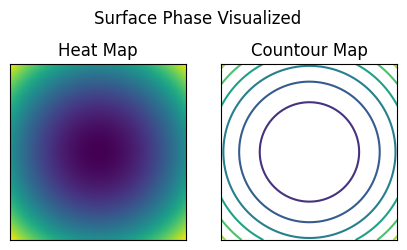

In [2]:
""" Construct our Surface """

# Generate a meshgrid from coordinate ranges:
N = 512

# Constructed such that phase ranges from 0 to 2pi:
X = Y = np.linspace(-1,1,512) * ((2*np.pi)**0.5)
X, Y = np.meshgrid(X, Y)

# Construct our surface:
PHASE = X**2 + Y**2

# Visualize:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(5,5))

ax1.set_title("Heat Map")
ax1.imshow(PHASE, cmap='viridis')

ax2.set_title("Countour Map")
ax2.contour(PHASE, cmap='viridis')
ax2.set_aspect("equal")

# Remove tick marks:
[ax.set_xticks([]) for ax in (ax1, ax2)]
[ax.set_yticks([]) for ax in (ax1, ax2)]

fig.suptitle("Surface Phase Visualized", y=0.78)
plt.show()

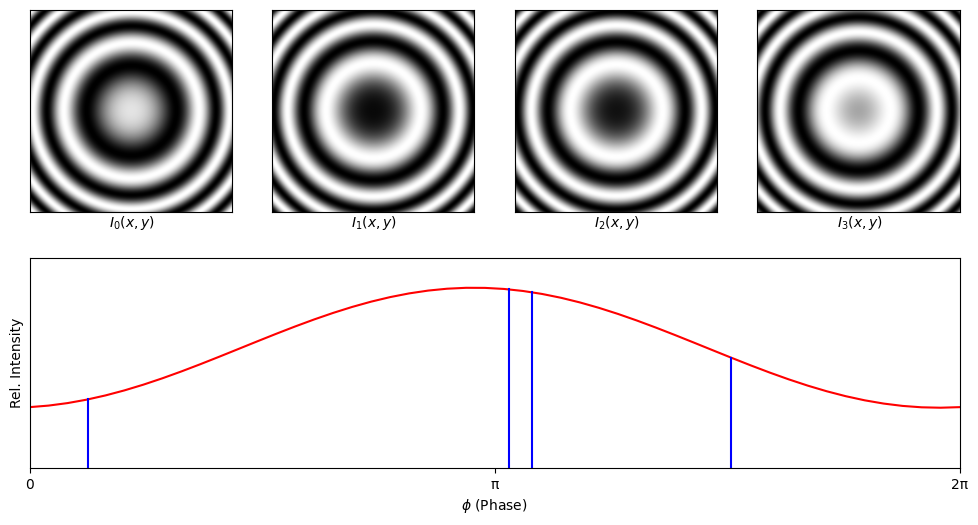

In [3]:
""" Create our interferograms """
rng = np.random.default_rng(seed=42)

# Random initial phase offset:
phase_offset = np.random.uniform(0,2*np.pi)

# Random sampling locations:
theta = np.random.uniform(0,2*np.pi,4)
# temp
theta = np.array([
    np.pi/8,
    np.pi + 0.1,
    np.pi + 0.25,
    np.pi + 1.6
])
theta.sort()


I = (1/2) + (1/2) * np.cos(
    2*(PHASE + phase_offset)[..., None] + theta[None, None, :]
)

fig = plt.figure(figsize=(12,6))

# Plot the interferograms at each theta:
for i in range(4):
    ax = plt.subplot2grid((2,4), (0,i), 1, 1)
    ax.imshow(I[...,i], cmap='gray')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(200,550,f"$I_{i}(x,y)$")


# Visualize where each theta is for the audience:
x = np.linspace(0,2*np.pi)
y = np.cos(x + phase_offset)

ax = plt.subplot2grid((2,4),(1,0),1,4)
ax.set_ylim(-2,1.5)


ax.set_xlim(0,2*np.pi)
ax.set_xticks([0, np.pi, 2*np.pi])
ax.set_xticklabels(["0", "π", "2π"])
ax.set_yticks([])
ax.plot(x,y, color="red")

ax.set_ylabel("Rel. Intensity")
ax.set_xlabel(r"$\phi$ (Phase)")

for i, t in enumerate(theta):
    c = np.cos(t + phase_offset)
    c += 1
    c *= 4/14
    c += 2/7
    ax.axvline(t, 0,c, color="blue")

### Step (1), Find the first analytic term $Z_1$ using basic PSA algorithm

Comments: They assume a phase step of $\frac{2\pi}{N}$, where $N$ is the number of steps (4).
    They're essentially assuming that the entire sampling region is within $2\pi$.
    phase steps, and that we are sampling at a uniform interval i.e., $(0, \pi/4, \pi/2, 3\pi/4)$.

The authors give us that 

$$
Z_1 = \sum_{n=0}^{N-1}e^{i(\frac{2\pi}{N})n} I_n
$$

They then show that this can be writen as the sum of the DC term, the positive phase signal and the negative phase signal. They comment that the DC term will sum to zero.

In [4]:
Z1 =  np.exp(np.arange(4) * (2*np.pi/4) * 1j)[None, None, :] * I
Z1 = np.sum(Z1, axis=-1)

### 3.2 Processing $Z_1$ with UPSA

In [5]:
Z2 = (
      (Z1.real / np.max(np.abs(Z1.real)))
    + (1j * (Z1.imag / np.max(np.abs(Z1.imag))))
)

Z3 = np.exp(1j * (np.pi/4)) * Z2
ZUPSA = (np.real(Z3) / np.max(np.abs(np.real(Z3)))) + 1j*(np.imag(Z3) / np.max(np.abs(np.imag(Z3))))

#### visualize figure 3

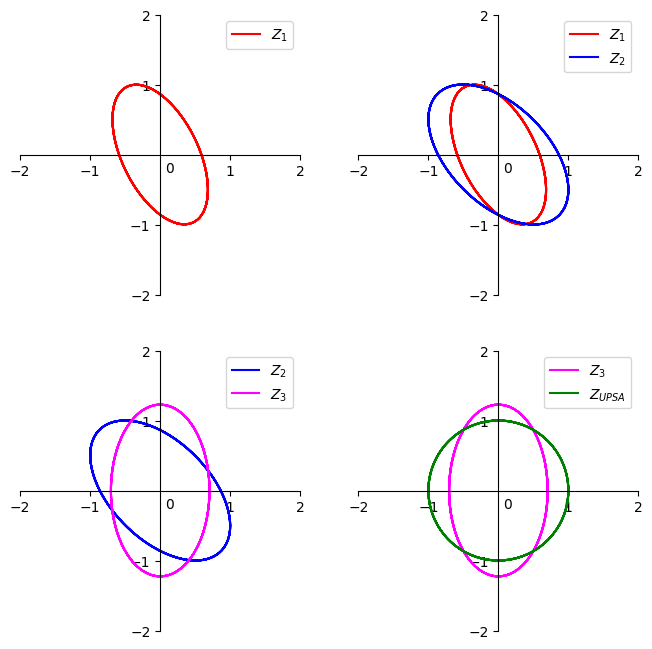

In [6]:
# Visualize the lissajous ellipse:
fig, ax = plt.subplots(2,2, figsize=(8,8))

# Plot the Lissajous figures:
ax[0,0].plot(np.imag(Z1[256,:]), np.real(Z1[256,:]), color="red", label="$Z_1$")

ax[0,1].plot(np.imag(Z1[256,:]), np.real(Z1[256,:]), color="red", label="$Z_1$")
ax[0,1].plot(np.imag(Z2[256,:]), np.real(Z2[256,:]), color="blue", label="$Z_2$")

ax[1,0].plot(np.imag(Z2[256,:]), np.real(Z2[256,:]), color="blue", label="$Z_2$")
ax[1,0].plot(np.imag(Z3[256,:]), np.real(Z3[256,:]), color="magenta", label="$Z_3$")

ax[1,1].plot(np.imag(Z3[256,:]), np.real(Z3[256,:]), color="magenta", label="$Z_3$")
ax[1,1].plot(np.imag(ZUPSA[256,:]), np.real(ZUPSA[256,:]), color="green", label="$Z_{UPSA}$")

# Fix axis:
for (i,j) in [(0,0),(0,1), (1,0), (1,1)]:  
    ax[i,j].spines["left"].set_position(("data", 0))
    ax[i,j].spines["bottom"].set_position(("data", 0))
    
    ax[i,j].spines["top"].set_visible(False)
    ax[i,j].spines["right"].set_visible(False)
    
    ax[i,j].set_yticks([-2, -1, 1, 2])
    ax[i,j].set_xticks([-2, -1, 1, 2])
    ax[i,j].text(0.07,-0.25,"0")
    
    ax[i,j].xaxis.set_ticks_position("bottom")
    ax[i,j].yaxis.set_ticks_position("left")

    ax[i,j].set_aspect("equal")

    ax[i,j].legend()

plt.show()

## 4. Null-testing for gauging experimental phase demodulation accuracy

The authors suggest gauging for phase demodulation accuracy via simply looking at the contrast of the analytic.

I think an obvious, but easy to skip over "gotcha" is to remember your scaling; most software will automatically scale to the minimum and maximum contrast. Make sure you manually set the scale to something consistent!

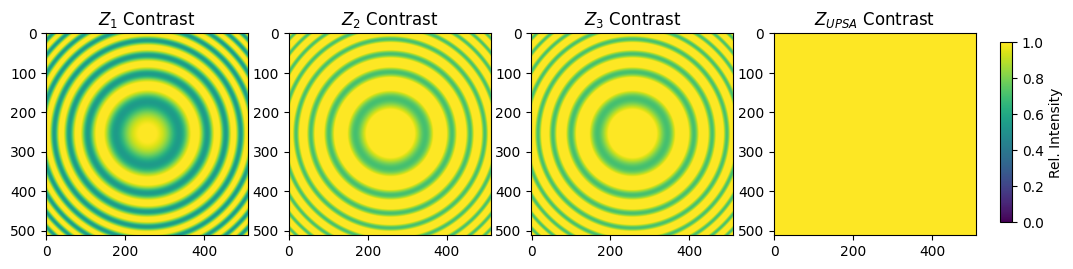

In [7]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1,4, figsize=(12,4))
cbar = fig.add_axes([0.92,0.275,0.01,0.45])

ax1.set_title("$Z_1$ Contrast")
ax1.imshow(np.abs(Z1), vmin=0, vmax=1)

ax2.set_title("$Z_2$ Contrast")
ax2.imshow(np.abs(Z2), vmin=0, vmax=1)

ax3.set_title("$Z_3$ Contrast")
ax3.imshow(np.abs(Z3), vmin=0, vmax=1)

ax4.set_title("$Z_{UPSA}$ Contrast")
im = ax4.imshow(np.abs(ZUPSA), vmin=0, vmax=1)

fig.colorbar(im, cax=cbar, label="Rel. Intensity")